# Exploratory Data Analysis (EDA)

This notebook covers the initial exploration and visualization of the customer data to understand its structure, distributions, and relationships.

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# Configuration
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# File Path
INPUT_FILE = 'data/customer_info.csv'

/Users/mateuscosta/Development/python-notebooks/CS-Project./venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [3]:
df = pd.read_csv(INPUT_FILE)
print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (16978, 25)


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,1553.0,1479.0,1580.0,2011.0,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
1,6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,2060.0,1549.0,2756.0,3575.0,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
2,14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,4905.0,2357.0,607.0,495.0,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
3,7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,2281.0,650.0,1102.0,3018.0,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4,4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,6068.0,3014.0,1974.0,6982.0,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


## 3. Initial Overview and Data Types

In [4]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16978 entries, 0 to 16977
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              16978 non-null  int64  
 1   customer_name                            16978 non-null  object 
 2   customer_gender                          16978 non-null  object 
 3   customer_birthdate                       16910 non-null  object 
 4   kids_home                                16893 non-null  float64
 5   teens_home                               16910 non-null  float64
 6   number_complaints                        16927 non-null  float64
 7   distinct_stores_visited                  16808 non-null  float64
 8   lifetime_spend_groceries                 16978 non-null  float64
 9   lifetime_spend_electronics               16978 non-null  float64
 10  typical_hour                             16910

In [5]:
# Descriptive Statistics for Numerical Features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,16978.0,9981.332195,5781.604623,1.000000,4973.250000,9950.500000,14999.750000,20000.000000
kids_home,16893.0,1.639792,1.529161,0.000000,0.000000,1.000000,3.000000,11.000000
teens_home,16910.0,1.085571,0.948280,0.000000,0.000000,1.000000,2.000000,5.000000
number_complaints,16927.0,1.103917,0.920515,0.000000,0.000000,1.000000,2.000000,7.000000
distinct_stores_visited,16808.0,1.984293,1.247115,1.000000,1.000000,2.000000,2.000000,10.000000
lifetime_spend_groceries,16978.0,26920.981034,19734.997961,10.000000,11344.500000,20783.500000,40250.250000,128132.000000
lifetime_spend_electronics,16978.0,2858.417069,2404.063138,0.000000,1269.000000,2370.000000,3573.750000,17407.000000
typical_hour,16910.0,14.665464,4.787448,6.000000,10.000000,15.000000,18.000000,24.000000
lifetime_spend_vegetables,16893.0,2769.181318,1787.447384,0.000000,1376.000000,2423.000000,3981.000000,10076.000000
lifetime_spend_nonalcohol_drinks,16978.0,2144.302980,1176.776175,0.000000,1218.000000,1999.000000,2911.750000,7490.000000


In [6]:
# Descriptive Statistics for Categorical Features
df.describe(include=['O', 'bool']).T

,count,unique,top,freq
customer_name,16978,16850,Robert Davis,4
customer_gender,16978,2,female,8580
customer_birthdate,16910,16902,08/14/1975 01:23 AM,2


In [7]:
# Check for missing values
print("Missing Values:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values:

customer_birthdate                 68
kids_home                          85
teens_home                         68
number_complaints                  51
distinct_stores_visited           170
typical_hour                       68
lifetime_spend_vegetables          85
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
loyalty_card_number              3143
dtype: int64


In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")


Duplicate rows: 0


## 4. Univariate Analysis

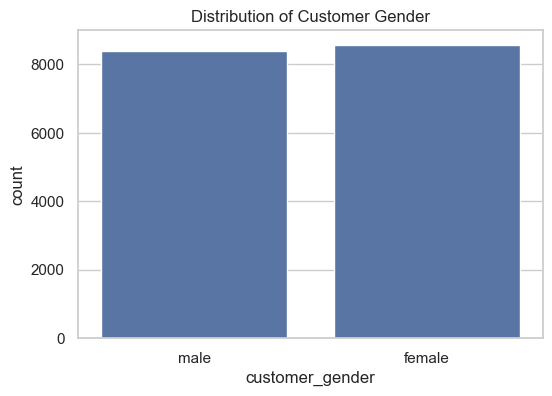

In [9]:
# Categorical Feature Distribution
categorical_cols = ['customer_gender', 'customer_name'] # Name is high cardinality, just checking gender here usually
# We'll assume encoded columns or raw text columns from the CSV structure seen in preview

if 'customer_gender' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='customer_gender')
    plt.title('Distribution of Customer Gender')
    plt.show()

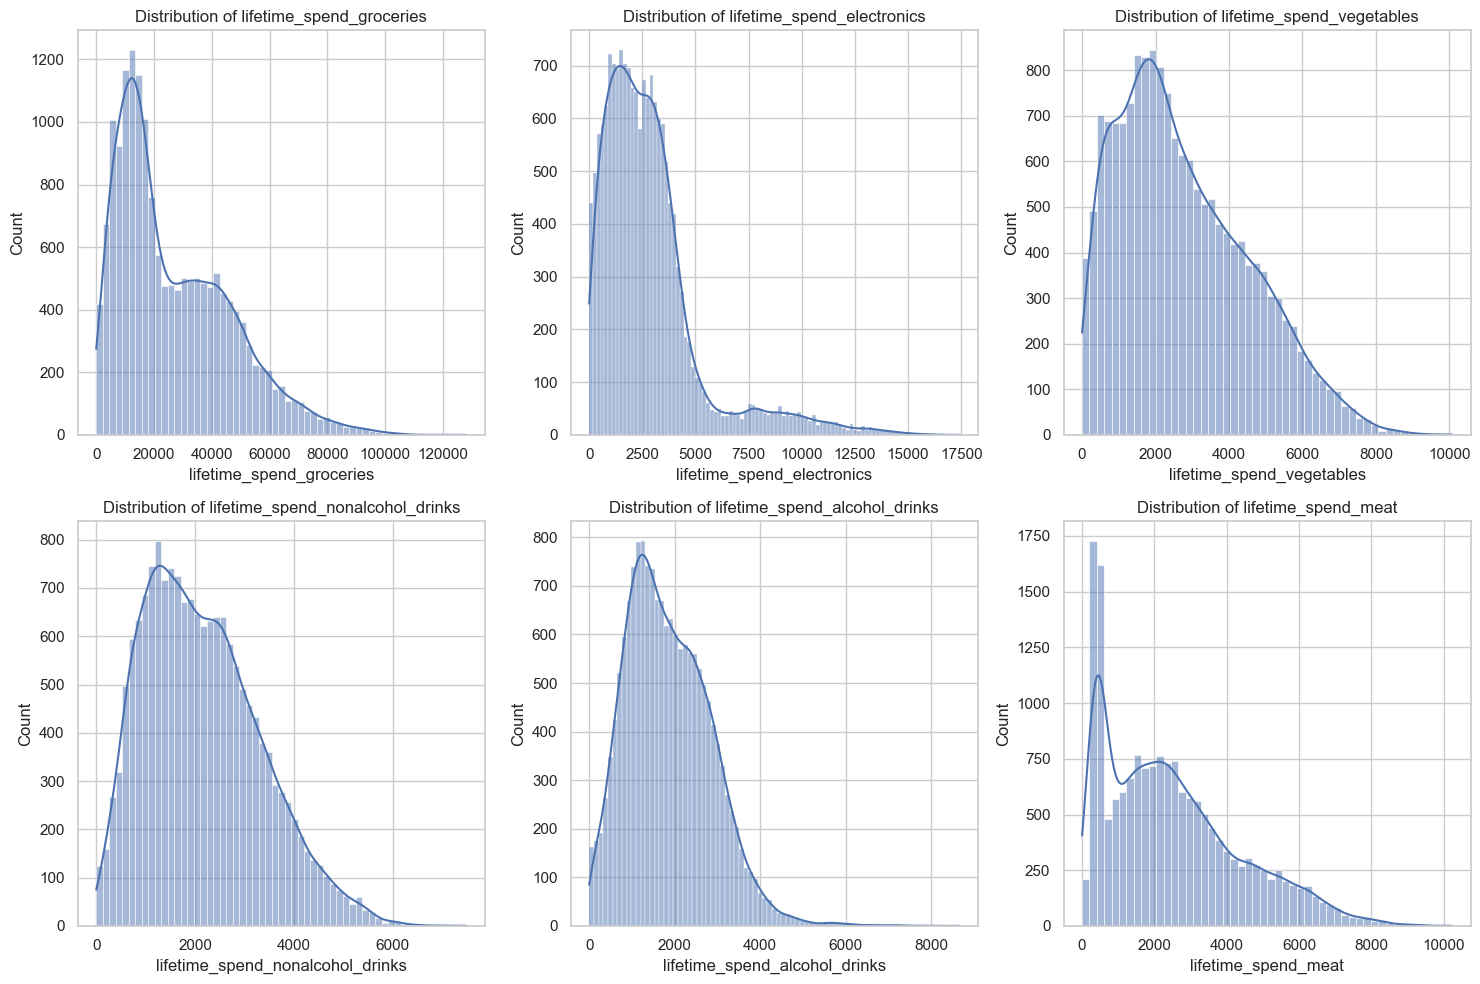

In [10]:
# Numerical Feature Distribution (Income)
if 'income' in df.columns: 
    # Note: Column names might default to Unnamed/etc if CSV headers are tricky, 
    # based on preprocessing notebook, columns seem standard.
    pass

# Let's visualize distributions of spending columns
spending_cols = [col for col in df.columns if 'lifetime_spend' in col]

if spending_cols:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(spending_cols[:6]): # Plot first 6 for visibility
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## 5. Bivariate Analysis

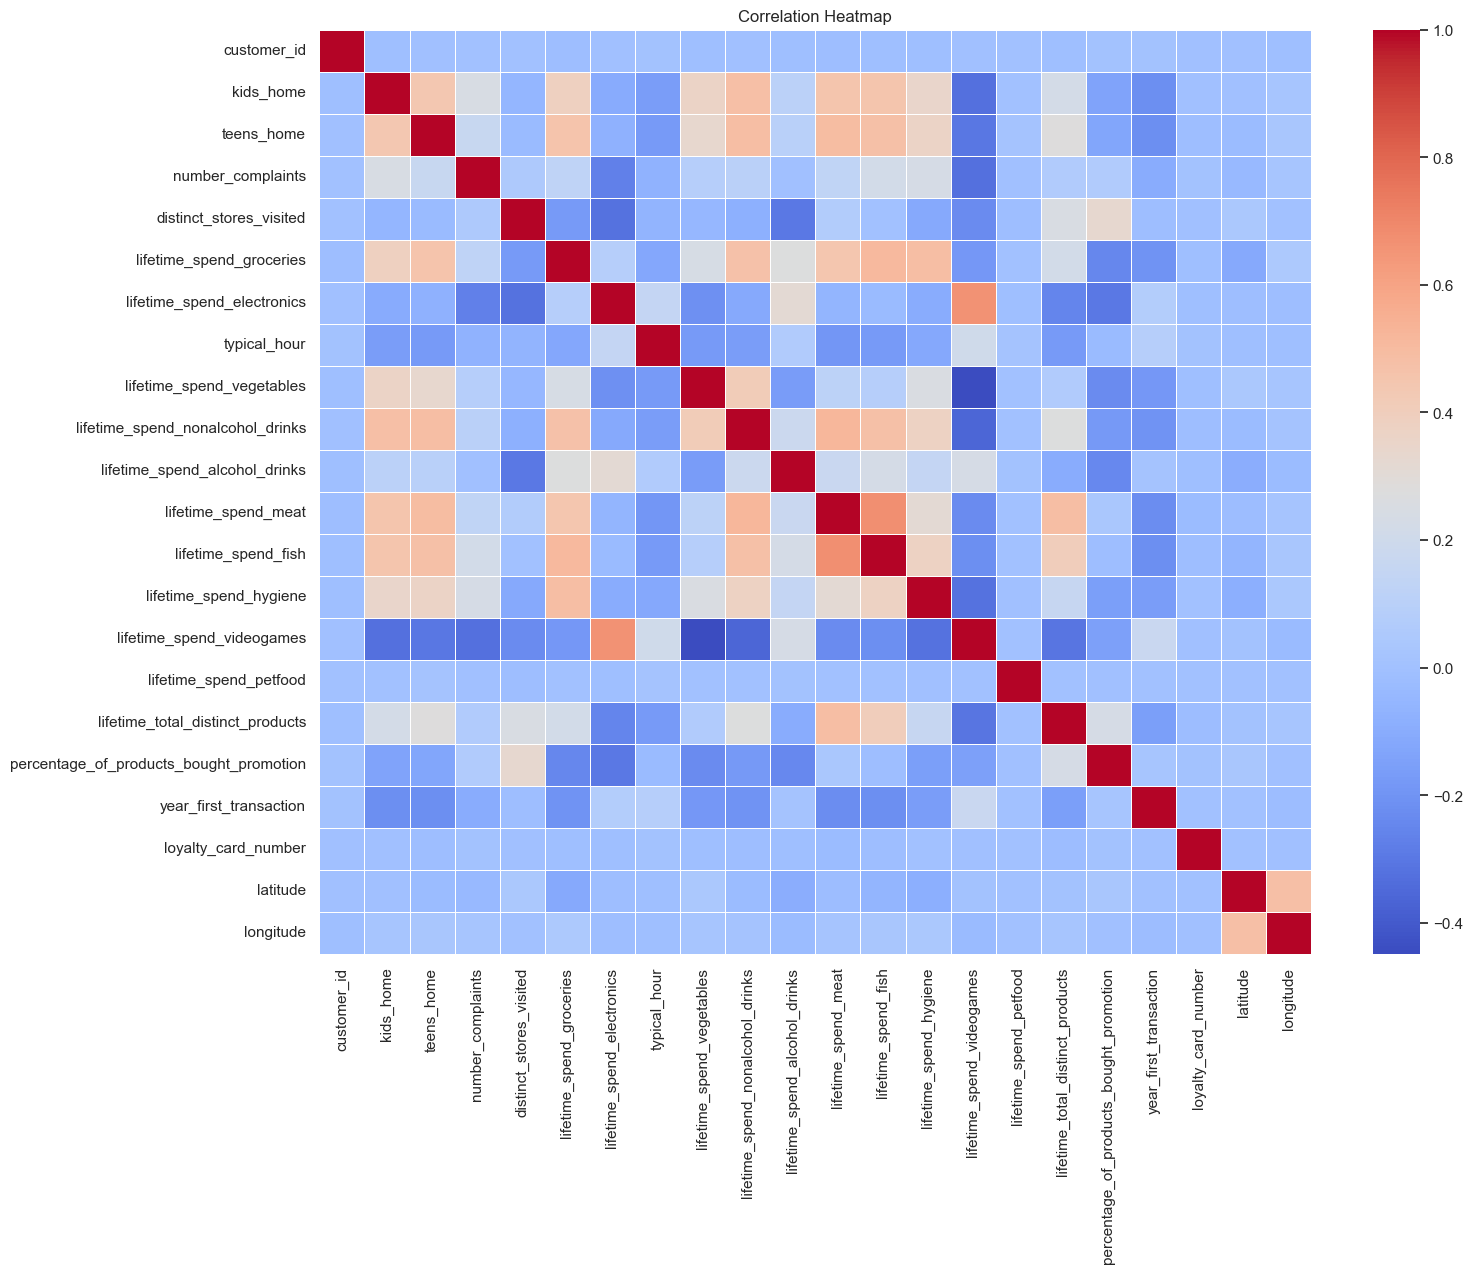

In [11]:
# Correlation Heatmap
numerical_df = df.select_dtypes(include=[np.number])
if not numerical_df.empty:
    plt.figure(figsize=(16, 12))
    correlation_matrix = numerical_df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()

## 6. Automated Profiling Report

In [12]:
# Generate Profile Report
# Warning: This can take a few minutes for large datasets
try:
    profile = ProfileReport(df, title="Customer Data Profiling Report", explorative=True)
    # To display in notebook:
    # profile.to_notebook_iframe()
    print("Profile report object created. Use profile.to_notebook_iframe() to view or profile.to_file() to save.")
except Exception as e:
    print(f"Could not generate profile report: {e}")

Profile report object created. Use profile.to_notebook_iframe() to view or profile.to_file() to save.
